# Self-Supervised / Unsupervised Seismic Resolution Enhancement 

This notebook builds a complete unsupervised workflow for temporal resolution enhancement using the reflectivity patches stored in:

- **File:** `SWAN_random_resolution.npz`
- **Key:** `patches`
- **Expected shape:** `(n_samples, 1024, 64)`

Each patch is interpreted as a 2D reflectivity image with `nt=1024` time samples and `nx=64` traces.


## Core idea

We assume the observed low-resolution seismic patch is generated by

$y = h_L * r + n$,

where:

- $y$ is the observed **low-resolution seismic data**
- $r$ is the unknown **reflectivity**
- $h_L$ is the **low-frequency wavelet**
- $n$ is noise
- $*$ denotes 1D convolution along time

The target high-resolution seismic patch is then generated by

$
x_H = h_H * r,
$

where $h_H$ is a **target high-frequency wavelet** chosen by the author.

So the workflow is:

$
\text{low-resolution seismic} \;\to\; \widehat{r} \;\to\; \widehat{x}_H
$

Instead of training against a known high-resolution label, we train the network by enforcing that the predicted reflectivity, when reconvolved with the low-resolution wavelet, reproduces the observed low-resolution input.

---

## What this notebook covers

1. Load the SWAN reflectivity dataset from `SWAN_random_resolution.npz`
2. Generate low-resolution observations using an author-defined low-frequency wavelet
3. Choose a target high-frequency wavelet for the desired enhanced output
4. Train a **self-supervised reflectivity inversion network**
5. Optionally make the low-resolution wavelet **learnable** for a semi-blind / blind-deconvolution style workflow
6. Reconstruct enhanced seismic data with the target wavelet
7. Visualize reflectivity, low-resolution input, reconstructed low-resolution data, and enhanced output
8. Quantitatively evaluate the result using the known synthetic reflectivity only for benchmarking

> Training is self-supervised: the loss uses **only the low-resolution input**.  
> The original reflectivity and high-resolution data are used **only for offline evaluation and illustration**.

---

## Why this is useful

This design is flexible because:

- the **input low-resolution wavelet** can be specified or estimated
- the **target high-resolution wavelet** can be changed at will
- the same inverted reflectivity can generate **multiple output resolutions**
- the workflow naturally connects **deconvolution**, **inverse problems**, and **deep learning**

## Mathematical formulation

### Forward model

For a patch with time index $t$ and trace index $x$,

$
y(t,x) = \sum_{\tau} h_L(\tau)\, r(t-\tau, x) + n(t,x).
$

In operator form,

$
y = \mathcal{H}_{L}(r) + n.
$

The enhancement target is

$
x_H = \mathcal{H}_{H}(r),
$

where $\mathcal{H}_{L}$ and $\mathcal{H}_{H}$ are 1D convolution operators along the time axis.

### Neural inversion model

We train a neural network $f_\theta$ to estimate reflectivity directly from the low-resolution input:

$
\widehat{r} = f_\theta(y).
$

Then:

$
\widehat{y} = \mathcal{H}_{L}(\widehat{r}),
\qquad
\widehat{x}_H = \mathcal{H}_{H}(\widehat{r}).
$

### Self-supervised loss

The primary self-supervised objective is the **data-consistency loss**:

$
\mathcal{L}_{\text{data}} = \frac{1}{N}\lVert \widehat{y} - y \rVert_1.
$

Because reflectivity is expected to be sparse and piecewise structured, we add priors:

$
\mathcal{L}_{\text{sparse}} = \frac{1}{N}\lVert \widehat{r} \rVert_1,
$

and anisotropic total variation:

$
\mathcal{L}_{\text{tv}} =
\frac{1}{N}
\left(
\lVert \nabla_t \widehat{r} \rVert_1 + \beta\, \lVert \nabla_x \widehat{r} \rVert_1
\right).
$

The total loss is

$
\mathcal{L}
=
\lambda_{\text{data}} \mathcal{L}_{\text{data}}
+
\lambda_{\text{sparse}} \mathcal{L}_{\text{sparse}}
+
\lambda_{\text{tv}} \mathcal{L}_{\text{tv}}.
$

### Optional blind / semi-blind wavelet learning

If the low-frequency wavelet is not fully known, we treat it as a learnable parameter $h_{L,\phi}$. Then

$
\widehat{y} = \mathcal{H}_{L,\phi}(\widehat{r}),
$

and add a weak wavelet prior:

$
\mathcal{L}_{\text{wavelet}}
=
\lVert h_{L,\phi} - h_{0} \rVert_2^2,
$

where $h_0$ is an initial guess, for example a Ricker wavelet with frequency estimated from the input data spectrum.

The blind loss becomes

$
\mathcal{L}_{\text{blind}}
=
\mathcal{L}
+
\lambda_{\text{wavelet}} \mathcal{L}_{\text{wavelet}}.
$

This is not a fully unconstrained blind deconvolution; it is a **stable semi-blind learning strategy**.

## Notebook setup

- Input dataset key: `patches`
- Expected shape: `(n_samples, 1024, 64)`
- Time convolution is applied along the **1024-sample time axis**
- Spatial axis contains **64 traces**
- Default model: a compact **Residual U-Net**
- Default training mode: **self-supervised**
- Optional mode: **semi-blind wavelet learning**

In [1]:

# Basic imports
import os
import math
import json
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["image.cmap"] = "gray"
torch.manual_seed(7)
np.random.seed(7)
random.seed(7)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [2]:

# =========================
# Configuration
# =========================

CFG = {
    # Paths
    "npz_path": "../dataset/SWAN_random_resolution.npz",   # change if needed

    # Data geometry
    "expected_nt": 1024,
    "expected_nx": 64,
    "transpose_if_needed": False,              # set True if your dataset is (N, 64, 1024)

    # Training subset controls
    "max_samples": 600,                        # reduce for fast demo; set None to use all
    "train_ratio": 0.80,
    "val_ratio": 0.10,
    "test_ratio": 0.10,

    # Sampling / wavelet
    "dt": 0.002,                               # 2 ms
    "low_freq_hz": 12.0,                       # low-resolution dominant frequency
    "high_freq_hz": 35.0,                      # target enhanced dominant frequency
    "wavelet_length_s": 0.192,
    "noise_std": 0.00,                         # optional Gaussian noise in low-res input

    # Blind / semi-blind mode
    "blind_mode": False,                       # False = known low wavelet, True = learn low wavelet
    "blind_init_mode": "estimate",             # "estimate" or "ricker"
    "blind_init_freq_hz": 10.0,
    "wavelet_prior_weight": 1e-3,

    # Model
    "base_channels": 16,
    "dropout": 0.0,

    # Optimization
    "batch_size": 8,
    "epochs": 12,
    "lr_model": 1e-3,
    "lr_wavelet": 5e-4,
    "num_workers": 0,

    # Loss weights
    "lambda_data": 1.0,
    "lambda_sparse": 1e-3,
    "lambda_tv": 5e-4,
    "tv_x_weight": 0.3,

    # Saving
    "save_dir": "runs_selfsupervised_resolution",
}

Path(CFG["save_dir"]).mkdir(parents=True, exist_ok=True)
print(json.dumps(CFG, indent=2))

{
  "npz_path": "../dataset/SWAN_random_resolution.npz",
  "expected_nt": 1024,
  "expected_nx": 64,
  "transpose_if_needed": false,
  "max_samples": 600,
  "train_ratio": 0.8,
  "val_ratio": 0.1,
  "test_ratio": 0.1,
  "dt": 0.002,
  "low_freq_hz": 12.0,
  "high_freq_hz": 35.0,
  "wavelet_length_s": 0.192,
  "noise_std": 0.0,
  "blind_mode": false,
  "blind_init_mode": "estimate",
  "blind_init_freq_hz": 10.0,
  "wavelet_prior_weight": 0.001,
  "base_channels": 16,
  "dropout": 0.0,
  "batch_size": 8,
  "epochs": 12,
  "lr_model": 0.001,
  "lr_wavelet": 0.0005,
  "num_workers": 0,
  "lambda_data": 1.0,
  "lambda_sparse": 0.001,
  "lambda_tv": 0.0005,
  "tv_x_weight": 0.3,
  "save_dir": "runs_selfsupervised_resolution"
}


## Utility functions

We use:
- a Ricker wavelet generator
- time-domain convolution along the time axis
- normalization helpers
- plotting utilities
- a simple dominant-frequency estimator for initializing semi-blind wavelet learning

In [3]:

def ricker(f0, dt, length_s=0.192):
    n = int(round(length_s / dt))
    n = n + 1 if n % 2 == 0 else n
    t = (np.arange(n) - n // 2) * dt
    pf2 = (np.pi * f0 * t) ** 2
    w = (1.0 - 2.0 * pf2) * np.exp(-pf2)
    w = w / (np.max(np.abs(w)) + 1e-12)
    return t.astype(np.float32), w.astype(np.float32)

def conv_time_same_np(img_tx, wavelet):
    # img_tx: (nt, nx), wavelet: (k,)
    nt, nx = img_tx.shape
    k = len(wavelet)
    pad = k // 2
    out = np.zeros_like(img_tx, dtype=np.float32)
    for ix in range(nx):
        tr = np.pad(img_tx[:, ix], (pad, pad), mode="reflect")
        out[:, ix] = np.convolve(tr, wavelet, mode="valid")
    return out.astype(np.float32)

def add_gaussian_noise(x, std=0.0):
    if std <= 0:
        return x
    return (x + std * np.random.randn(*x.shape)).astype(np.float32)

def robust_scale_per_sample(x, eps=1e-8):
    # x: (nt, nx)
    s = np.percentile(np.abs(x), 99.0) + eps
    return (x / s).astype(np.float32), float(s)

def estimate_dominant_freq_from_patch(y_tx, dt):
    # Use average amplitude spectrum across traces
    nt, nx = y_tx.shape
    spec = 0.0
    for ix in range(nx):
        tr = y_tx[:, ix]
        amp = np.abs(np.fft.rfft(tr))
        spec += amp
    spec /= nx
    freqs = np.fft.rfftfreq(nt, d=dt)

    # Ignore DC and very low frequencies
    mask = (freqs >= 3.0) & (freqs <= 0.45 / dt)
    if np.any(mask):
        f_est = freqs[mask][np.argmax(spec[mask])]
    else:
        f_est = 10.0
    return float(f_est)

def show_gather(img, title="", aspect="auto", clip=1.0):
    vmax = np.percentile(np.abs(img), 99.5) * clip + 1e-12
    plt.figure(figsize=(6, 6))
    plt.imshow(img, aspect=aspect, cmap="gray", vmin=-vmax, vmax=vmax)
    plt.title(title)
    plt.xlabel("Trace")
    plt.ylabel("Time sample")
    plt.tight_layout()
    plt.show()

def show_three(a, b, c, titles=("A", "B", "C"), clip=1.0):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for ax, img, ttl in zip(axes, [a, b, c], titles):
        vmax = np.percentile(np.abs(img), 99.5) * clip + 1e-12
        ax.imshow(img, aspect="auto", cmap="gray", vmin=-vmax, vmax=vmax)
        ax.set_title(ttl)
        ax.set_xlabel("Trace")
        ax.set_ylabel("Time")
    plt.tight_layout()
    plt.show()

def show_wavelets(w_low, w_high, dt):
    t_low = (np.arange(len(w_low)) - len(w_low)//2) * dt
    t_high = (np.arange(len(w_high)) - len(w_high)//2) * dt
    plt.figure(figsize=(10, 3))
    plt.plot(t_low, w_low, label="Low-resolution wavelet")
    plt.plot(t_high, w_high, label="High-resolution wavelet")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title("Wavelets")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Load the dataset

The dataset stores **reflectivity patches**, not fixed low-resolution or high-resolution seismic pairs.  
That is exactly what makes the dataset flexible for self-supervised inversion and resolution transfer.

Keys: ['patches']
Original shape: (1000, 1024, 64)
Using shape: (600, 1024, 64)


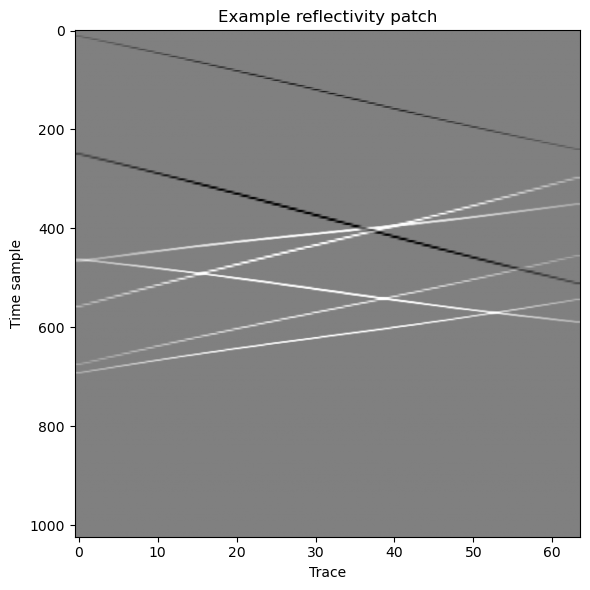

In [4]:

# =========================
# Load reflectivity patches
# =========================
data = np.load(CFG["npz_path"])
print("Keys:", list(data.keys()))

R = data["patches"].astype(np.float32)
print("Original shape:", R.shape)

if CFG["transpose_if_needed"]:
    R = np.transpose(R, (0, 2, 1))
    print("Transposed shape:", R.shape)

assert R.ndim == 3, "Expected patches with shape (N, nt, nx)"
assert R.shape[1] == CFG["expected_nt"], f"Expected nt={CFG['expected_nt']}, got {R.shape[1]}"
assert R.shape[2] == CFG["expected_nx"], f"Expected nx={CFG['expected_nx']}, got {R.shape[2]}"

if CFG["max_samples"] is not None:
    R = R[:CFG["max_samples"]]

print("Using shape:", R.shape)
show_gather(R[0], title="Example reflectivity patch")

## Author-defined low- and high-frequency wavelets

These are the two wavelets that define the experiment:

- **Low-frequency wavelet** $h_L$: produces the observed low-resolution input
- **High-frequency wavelet** $h_H$: defines the target enhanced output

Because the dataset stores reflectivity, you can re-run the entire notebook with different frequencies very easily.

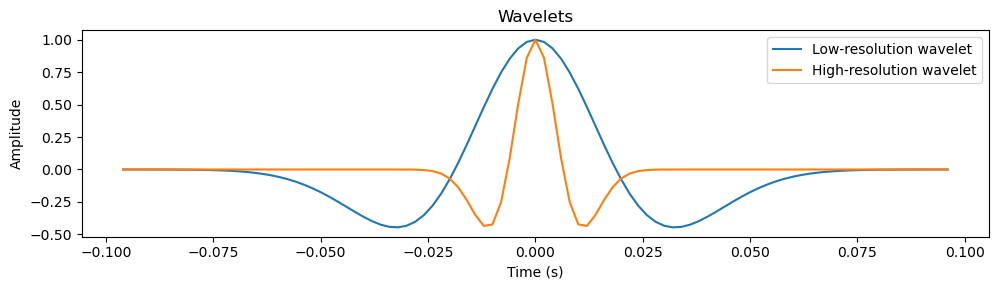

Low-frequency dominant frequency  (Hz): 12.0
High-frequency dominant frequency (Hz): 35.0
Wavelet length samples: 97


In [5]:

# Create wavelets
_, w_low_true = ricker(CFG["low_freq_hz"], CFG["dt"], CFG["wavelet_length_s"])
_, w_high = ricker(CFG["high_freq_hz"], CFG["dt"], CFG["wavelet_length_s"])

show_wavelets(w_low_true, w_high, CFG["dt"])

print("Low-frequency dominant frequency  (Hz):", CFG["low_freq_hz"])
print("High-frequency dominant frequency (Hz):", CFG["high_freq_hz"])
print("Wavelet length samples:", len(w_low_true))

## Build low-resolution observations and evaluation targets

For each reflectivity patch $r$:

- low-resolution observation: $y = h_L * r + n$
- evaluation-only high-resolution reference: $x_H = h_H * r$

Again, note that the **training loss will only see** $y$, not $r$ or $x_H$.

Reflectivity: (600, 1024, 64)
Low-resolution input: (600, 1024, 64)
High-resolution reference (evaluation only): (600, 1024, 64)


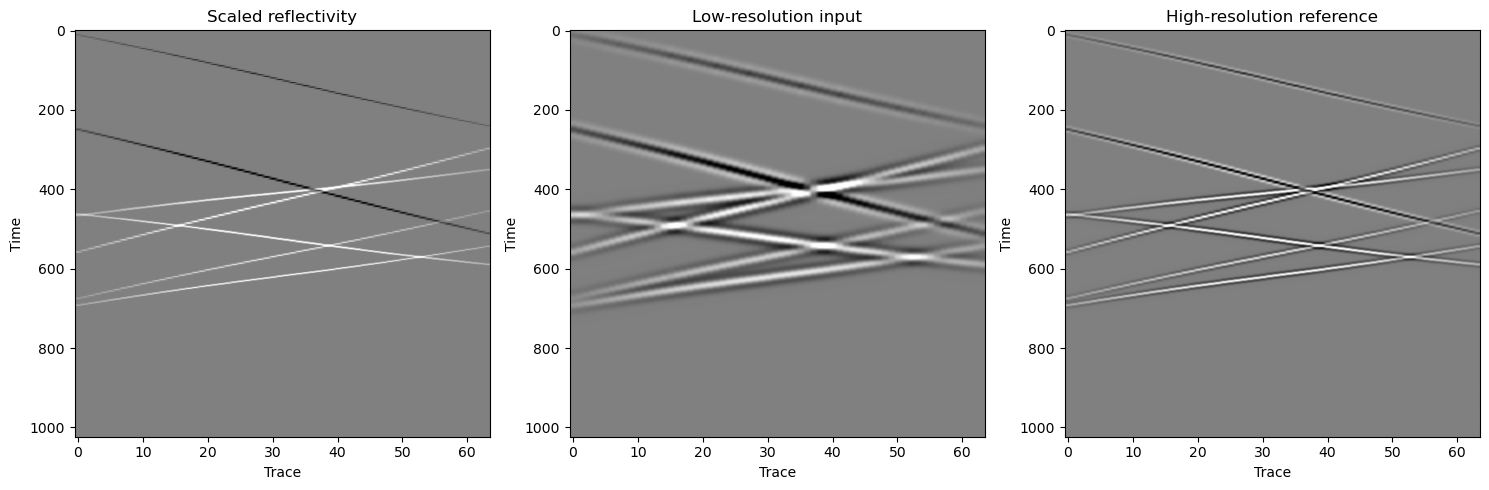

In [6]:

def build_low_and_high_from_reflectivity(R, w_low, w_high, noise_std=0.0):
    Y_low = []
    X_high = []
    scales = []
    for i in range(len(R)):
        low = conv_time_same_np(R[i], w_low)
        low = add_gaussian_noise(low, std=noise_std)
        high = conv_time_same_np(R[i], w_high)

        low, scale = robust_scale_per_sample(low)
        high = (high / scale).astype(np.float32)
        ref = (R[i] / scale).astype(np.float32)

        Y_low.append(low)
        X_high.append(high)
        scales.append(scale)
        R[i] = ref

    return R.astype(np.float32), np.stack(Y_low), np.stack(X_high), np.array(scales, dtype=np.float32)

R_scaled = R.copy()
R_scaled, Y_low, X_high_ref, scales = build_low_and_high_from_reflectivity(
    R_scaled, w_low_true, w_high, noise_std=CFG["noise_std"]
)

print("Reflectivity:", R_scaled.shape)
print("Low-resolution input:", Y_low.shape)
print("High-resolution reference (evaluation only):", X_high_ref.shape)

show_three(
    R_scaled[0], Y_low[0], X_high_ref[0],
    titles=("Scaled reflectivity", "Low-resolution input", "High-resolution reference")
)

## Optional initialization for blind / semi-blind low-wavelet learning

If `blind_mode=True`, the notebook initializes the low wavelet in one of two ways:

1. **`ricker`**: a user-chosen initial Ricker wavelet
2. **`estimate`**: estimate dominant frequency from the input data and initialize a Ricker wavelet from that estimate

This is a simple and stable educational approximation to blind deconvolution.

Estimated dominant frequency from first low-resolution patch: 11.72 Hz


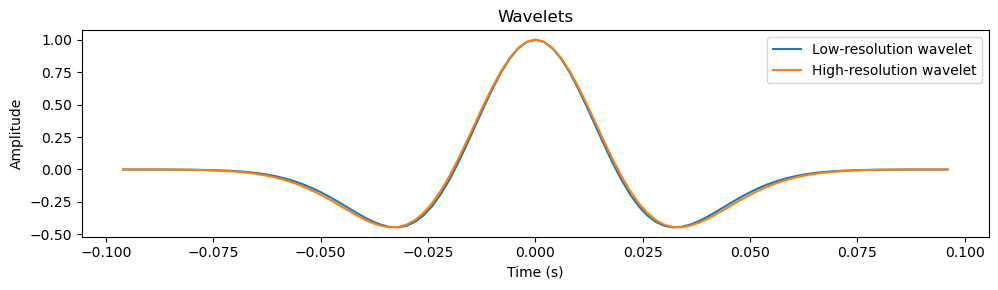

Blind initialization frequency (Hz): 11.719


In [7]:

f_est = estimate_dominant_freq_from_patch(Y_low[0], CFG["dt"])
print("Estimated dominant frequency from first low-resolution patch: %.2f Hz" % f_est)

if CFG["blind_init_mode"] == "estimate":
    f_init = f_est
else:
    f_init = CFG["blind_init_freq_hz"]

_, w_low_init = ricker(f_init, CFG["dt"], CFG["wavelet_length_s"])

show_wavelets(w_low_true, w_low_init, CFG["dt"])
print("Blind initialization frequency (Hz):", round(f_init, 3))

## Dataset object

The dataset returns:

- low-resolution input
- reflectivity (for evaluation only)
- high-resolution reference (for evaluation only)

During training, the optimization uses **only the low-resolution input**.

In [8]:

class SelfSupervisedResolutionDataset(Dataset):
    def __init__(self, y_low, r_true, x_high_ref):
        self.y_low = y_low.astype(np.float32)
        self.r_true = r_true.astype(np.float32)
        self.x_high_ref = x_high_ref.astype(np.float32)

    def __len__(self):
        return len(self.y_low)

    def __getitem__(self, idx):
        # Channel-first: (1, nt, nx)
        y = torch.from_numpy(self.y_low[idx][None, ...])
        r = torch.from_numpy(self.r_true[idx][None, ...])
        xh = torch.from_numpy(self.x_high_ref[idx][None, ...])
        return {
            "y_low": y,
            "r_true": r,
            "x_high_ref": xh,
        }

full_ds = SelfSupervisedResolutionDataset(Y_low, R_scaled, X_high_ref)

n_total = len(full_ds)
n_train = int(n_total * CFG["train_ratio"])
n_val = int(n_total * CFG["val_ratio"])
n_test = n_total - n_train - n_val

train_ds, val_ds, test_ds = random_split(
    full_ds,
    [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(7)
)

train_loader = DataLoader(train_ds, batch_size=CFG["batch_size"], shuffle=True, num_workers=CFG["num_workers"])
val_loader = DataLoader(val_ds, batch_size=CFG["batch_size"], shuffle=False, num_workers=CFG["num_workers"])
test_loader = DataLoader(test_ds, batch_size=CFG["batch_size"], shuffle=False, num_workers=CFG["num_workers"])

print(f"Train: {len(train_ds)}, Val: {len(val_ds)}, Test: {len(test_ds)}")

Train: 480, Val: 60, Test: 60


## Model: compact Residual U-Net

The network predicts reflectivity directly:

$\widehat{r} = f_\theta(y)$.

A U-Net is a good fit because it combines:

- local detail extraction
- multi-scale context
- skip connections that help preserve event geometry

We keep the network compact so the notebook remains easy to run on modest hardware.

In [9]:

class ConvBlock(nn.Module):
    def __init__(self, cin, cout, dropout=0.0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(cin, cout, 3, padding=1),
            nn.BatchNorm2d(cout),
            nn.GELU(),
            nn.Conv2d(cout, cout, 3, padding=1),
            nn.BatchNorm2d(cout),
            nn.GELU(),
            nn.Dropout2d(dropout) if dropout > 0 else nn.Identity(),
        )
        self.skip = nn.Conv2d(cin, cout, 1) if cin != cout else nn.Identity()

    def forward(self, x):
        return self.block(x) + self.skip(x)

class Down(nn.Module):
    def __init__(self, cin, cout, dropout=0.0):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = ConvBlock(cin, cout, dropout=dropout)

    def forward(self, x):
        return self.conv(self.pool(x))

class Up(nn.Module):
    def __init__(self, cin, cout, dropout=0.0):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.conv = ConvBlock(cin, cout, dropout=dropout)

    def forward(self, x, skip):
        x = self.up(x)
        # Pad if needed due to odd shapes
        dh = skip.shape[-2] - x.shape[-2]
        dw = skip.shape[-1] - x.shape[-1]
        x = F.pad(x, [dw // 2, dw - dw // 2, dh // 2, dh - dh // 2])
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)

class ReflectivityUNet(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, base=16, dropout=0.0):
        super().__init__()
        self.inp = ConvBlock(in_ch, base, dropout=dropout)
        self.d1 = Down(base, base * 2, dropout=dropout)
        self.d2 = Down(base * 2, base * 4, dropout=dropout)
        self.d3 = Down(base * 4, base * 8, dropout=dropout)
        self.mid = ConvBlock(base * 8, base * 8, dropout=dropout)
        self.u3 = Up(base * 8 + base * 8, base * 4, dropout=dropout)
        self.u2 = Up(base * 4 + base * 4, base * 2, dropout=dropout)
        self.u1 = Up(base * 2 + base * 2, base, dropout=dropout)
        self.out = nn.Conv2d(base + base, out_ch, kernel_size=1)

    def forward(self, x):
        s0 = self.inp(x)
        s1 = self.d1(s0)
        s2 = self.d2(s1)
        s3 = self.d3(s2)
        m = self.mid(s3)
        u3 = self.u3(m, s3)
        u2 = self.u2(u3, s2)
        u1 = self.u1(u2, s1)

        # final high-resolution fusion
        up0 = F.interpolate(u1, size=s0.shape[-2:], mode="bilinear", align_corners=False)
        z = torch.cat([up0, s0], dim=1)
        rhat = self.out(z)
        return rhat

model = ReflectivityUNet(base=CFG["base_channels"], dropout=CFG["dropout"]).to(device)
print(model.__class__.__name__)
sum(p.numel() for p in model.parameters()) / 1e6

ReflectivityUNet


0.865121

## Differentiable wavelet convolution layer

We convolve **along time only**, independently for each trace.  
In PyTorch this is efficiently implemented with grouped `conv1d`.

If blind mode is enabled, the low wavelet is learnable.

In [10]:

def conv_time_torch(x, wavelet):
    '''
    x: (B, 1, nt, nx)
    wavelet: (k,)
    returns: (B, 1, nt, nx)
    '''
    B, C, nt, nx = x.shape
    assert C == 1

    x2 = x.permute(0, 3, 1, 2).reshape(B * nx, 1, nt)          # (B*nx, 1, nt)
    w = wavelet.view(1, 1, -1)
    pad = wavelet.numel() // 2
    x2 = F.pad(x2, (pad, pad), mode="reflect")
    y2 = F.conv1d(x2, w)
    y = y2.reshape(B, nx, 1, nt).permute(0, 2, 3, 1)           # (B,1,nt,nx)
    return y

class LearnableWavelet(nn.Module):
    def __init__(self, init_wavelet):
        super().__init__()
        self.raw = nn.Parameter(torch.tensor(init_wavelet, dtype=torch.float32))

    def forward(self):
        # Normalize for amplitude stability
        w = self.raw - self.raw.mean()
        w = w / (w.abs().max() + 1e-8)
        return w

known_w_low = torch.tensor(w_low_true, dtype=torch.float32, device=device)
known_w_high = torch.tensor(w_high, dtype=torch.float32, device=device)

if CFG["blind_mode"]:
    wavelet_module = LearnableWavelet(w_low_init).to(device)
    w_low_prior = torch.tensor(w_low_init, dtype=torch.float32, device=device)
else:
    wavelet_module = None
    w_low_prior = None

## Loss functions

Training uses only the low-resolution input $y$ and the wavelet physics.

### 1. Data consistency

$
\mathcal{L}_{\text{data}} = \lVert \mathcal{H}_L(\widehat{r}) - y \rVert_1
$

### 2. Reflectivity sparsity prior

$
\mathcal{L}_{\text{sparse}} = \lVert \widehat{r} \rVert_1
$

### 3. Total variation prior

$
\mathcal{L}_{\text{tv}} =
\lVert \nabla_t \widehat{r} \rVert_1
+
\beta \lVert \nabla_x \widehat{r} \rVert_1
$

### 4. Optional wavelet prior

$
\mathcal{L}_{\text{wavelet}} = \lVert h_{L,\phi} - h_0 \rVert_2^2
$

The high-resolution output is then synthesized as

$
\widehat{x}_H = \mathcal{H}_H(\widehat{r}).
$

In [11]:

def tv_loss(x, x_weight=0.3):
    dtv = torch.mean(torch.abs(x[:, :, 1:, :] - x[:, :, :-1, :]))
    dxv = torch.mean(torch.abs(x[:, :, :, 1:] - x[:, :, :, :-1]))
    return dtv + x_weight * dxv

def compute_losses(batch, model, known_w_low, known_w_high, cfg, wavelet_module=None, w_low_prior=None):
    y = batch["y_low"].to(device)                       # observed low-resolution data
    rhat = model(y)                                    # reflectivity estimate

    if wavelet_module is None:
        wlow = known_w_low
        lwave = torch.tensor(0.0, device=device)
    else:
        wlow = wavelet_module()
        lwave = torch.mean((wlow - w_low_prior) ** 2)

    yrec = conv_time_torch(rhat, wlow)                 # should match y
    xh_pred = conv_time_torch(rhat, known_w_high)      # enhanced output

    l_data = torch.mean(torch.abs(yrec - y))
    l_sparse = torch.mean(torch.abs(rhat))
    l_tv = tv_loss(rhat, x_weight=cfg["tv_x_weight"])

    total = (
        cfg["lambda_data"] * l_data
        + cfg["lambda_sparse"] * l_sparse
        + cfg["lambda_tv"] * l_tv
        + cfg["wavelet_prior_weight"] * lwave
    )

    logs = {
        "loss": float(total.detach().cpu()),
        "l_data": float(l_data.detach().cpu()),
        "l_sparse": float(l_sparse.detach().cpu()),
        "l_tv": float(l_tv.detach().cpu()),
        "l_wavelet": float(lwave.detach().cpu()),
    }

    return total, logs, rhat, yrec, xh_pred

## Optimizer setup

If `blind_mode=False`, only the network is learned.

If `blind_mode=True`, the network and the low wavelet are jointly optimized with separate learning rates.

In [12]:

params = [{"params": model.parameters(), "lr": CFG["lr_model"]}]
if wavelet_module is not None:
    params.append({"params": wavelet_module.parameters(), "lr": CFG["lr_wavelet"]})

optimizer = torch.optim.Adam(params)

## Training and validation loops

In [13]:

def run_epoch(loader, model, cfg, optimizer=None, train=True, wavelet_module=None):
    model.train(train)
    meter = {"loss": 0.0, "l_data": 0.0, "l_sparse": 0.0, "l_tv": 0.0, "l_wavelet": 0.0}
    n = 0

    for batch in loader:
        if train:
            optimizer.zero_grad()

        loss, logs, rhat, yrec, xh_pred = compute_losses(
            batch=batch,
            model=model,
            known_w_low=known_w_low,
            known_w_high=known_w_high,
            cfg=cfg,
            wavelet_module=wavelet_module,
            w_low_prior=w_low_prior,
        )

        if train:
            loss.backward()
            optimizer.step()

        bs = batch["y_low"].shape[0]
        n += bs
        for k in meter:
            meter[k] += logs[k] * bs

    for k in meter:
        meter[k] /= max(n, 1)

    return meter

history = []

for epoch in range(1, CFG["epochs"] + 1):
    train_logs = run_epoch(
        train_loader, model, CFG,
        optimizer=optimizer, train=True, wavelet_module=wavelet_module
    )
    val_logs = run_epoch(
        val_loader, model, CFG,
        optimizer=None, train=False, wavelet_module=wavelet_module
    )

    row = {"epoch": epoch}
    row.update({f"train_{k}": v for k, v in train_logs.items()})
    row.update({f"val_{k}": v for k, v in val_logs.items()})
    history.append(row)

    print(
        f"Epoch {epoch:02d} | "
        f"train loss={train_logs['loss']:.5f}, data={train_logs['l_data']:.5f} | "
        f"val loss={val_logs['loss']:.5f}, data={val_logs['l_data']:.5f}"
    )

Epoch 01 | train loss=0.18900, data=0.18895 | val loss=0.08219, data=0.08217
Epoch 02 | train loss=0.07322, data=0.07320 | val loss=0.05978, data=0.05976
Epoch 03 | train loss=0.04897, data=0.04895 | val loss=0.04716, data=0.04714
Epoch 04 | train loss=0.04301, data=0.04299 | val loss=0.04403, data=0.04402
Epoch 05 | train loss=0.03848, data=0.03847 | val loss=0.03719, data=0.03718
Epoch 06 | train loss=0.03512, data=0.03511 | val loss=0.03922, data=0.03921
Epoch 07 | train loss=0.03114, data=0.03113 | val loss=0.02859, data=0.02858
Epoch 08 | train loss=0.02642, data=0.02641 | val loss=0.02349, data=0.02348
Epoch 09 | train loss=0.02781, data=0.02780 | val loss=0.03048, data=0.03047
Epoch 10 | train loss=0.02821, data=0.02820 | val loss=0.03434, data=0.03433
Epoch 11 | train loss=0.02178, data=0.02177 | val loss=0.01948, data=0.01947
Epoch 12 | train loss=0.02216, data=0.02215 | val loss=0.02443, data=0.02443


## Training curves

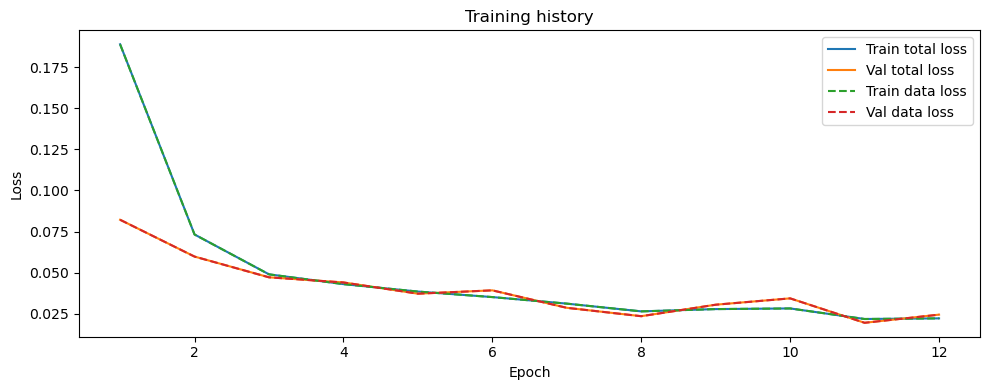

In [14]:

epochs = [h["epoch"] for h in history]
train_loss = [h["train_loss"] for h in history]
val_loss = [h["val_loss"] for h in history]
train_data = [h["train_l_data"] for h in history]
val_data = [h["val_l_data"] for h in history]

plt.figure(figsize=(10, 4))
plt.plot(epochs, train_loss, label="Train total loss")
plt.plot(epochs, val_loss, label="Val total loss")
plt.plot(epochs, train_data, "--", label="Train data loss")
plt.plot(epochs, val_data, "--", label="Val data loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training history")
plt.legend()
plt.tight_layout()
plt.show()

## Inspect the learned low wavelet

If blind mode is enabled, compare:

- true low wavelet
- initialization
- learned wavelet

This shows whether the semi-blind scheme successfully refined the wavelet.

In [15]:

if CFG["blind_mode"]:
    w_learned = wavelet_module().detach().cpu().numpy()
    t = (np.arange(len(w_low_true)) - len(w_low_true)//2) * CFG["dt"]

    plt.figure(figsize=(10, 3))
    plt.plot(t, w_low_true, label="True low wavelet")
    plt.plot(t, w_low_init, label="Initial guess", linestyle="--")
    plt.plot(t, w_learned, label="Learned wavelet", linewidth=2)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.title("Semi-blind wavelet learning")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("blind_mode=False, so the low wavelet is fixed and known.")

blind_mode=False, so the low wavelet is fixed and known.


## Evaluation metrics

Although training is self-supervised, this synthetic dataset lets us benchmark against known reflectivity and known high-resolution reference.

We compute:

- MAE on the low-resolution reconstruction
- MAE on reflectivity
- MAE on the enhanced output
- SNR of the enhanced output

In [16]:

def snr_db(true, pred, eps=1e-8):
    num = np.sum(true ** 2)
    den = np.sum((true - pred) ** 2) + eps
    return 10.0 * np.log10((num + eps) / den)

@torch.no_grad()
def evaluate_model(loader, model, cfg, wavelet_module=None):
    model.eval()
    rows = []
    preds = []

    for batch in loader:
        y = batch["y_low"].to(device)
        r_true = batch["r_true"].to(device)
        xh_true = batch["x_high_ref"].to(device)

        rhat = model(y)
        if wavelet_module is None:
            wlow = known_w_low
        else:
            wlow = wavelet_module()

        yrec = conv_time_torch(rhat, wlow)
        xh_pred = conv_time_torch(rhat, known_w_high)

        for i in range(y.shape[0]):
            y_i = y[i, 0].cpu().numpy()
            yrec_i = yrec[i, 0].cpu().numpy()
            r_i = r_true[i, 0].cpu().numpy()
            rhat_i = rhat[i, 0].cpu().numpy()
            xh_i = xh_true[i, 0].cpu().numpy()
            xhp_i = xh_pred[i, 0].cpu().numpy()

            rows.append({
                "mae_low_rec": float(np.mean(np.abs(y_i - yrec_i))),
                "mae_reflectivity": float(np.mean(np.abs(r_i - rhat_i))),
                "mae_high": float(np.mean(np.abs(xh_i - xhp_i))),
                "snr_high_db": float(snr_db(xh_i, xhp_i)),
            })

            preds.append({
                "y_low": y_i,
                "y_rec": yrec_i,
                "r_true": r_i,
                "r_hat": rhat_i,
                "xh_true": xh_i,
                "xh_pred": xhp_i,
            })

    # Aggregate
    keys = rows[0].keys()
    summary = {k: float(np.mean([r[k] for r in rows])) for k in keys}
    return summary, rows, preds

test_summary, test_rows, test_preds = evaluate_model(test_loader, model, CFG, wavelet_module=wavelet_module)
test_summary

{'mae_low_rec': 0.024617274043460688,
 'mae_reflectivity': 0.007930512470193208,
 'mae_high': 0.03285319712013006,
 'snr_high_db': 0.6204698010037343}

## Test summary

In [17]:

for k, v in test_summary.items():
    print(f"{k:>18s}: {v:.6f}")

       mae_low_rec: 0.024617
  mae_reflectivity: 0.007931
          mae_high: 0.032853
       snr_high_db: 0.620470


## Visual inspection on test samples

For each test example we show:

1. observed low-resolution input
2. reconstructed low-resolution data
3. true reflectivity
4. predicted reflectivity
5. true high-resolution reference
6. predicted enhanced output

The most important physics check is whether the predicted reflectivity reconvolves back to the input low-resolution data.

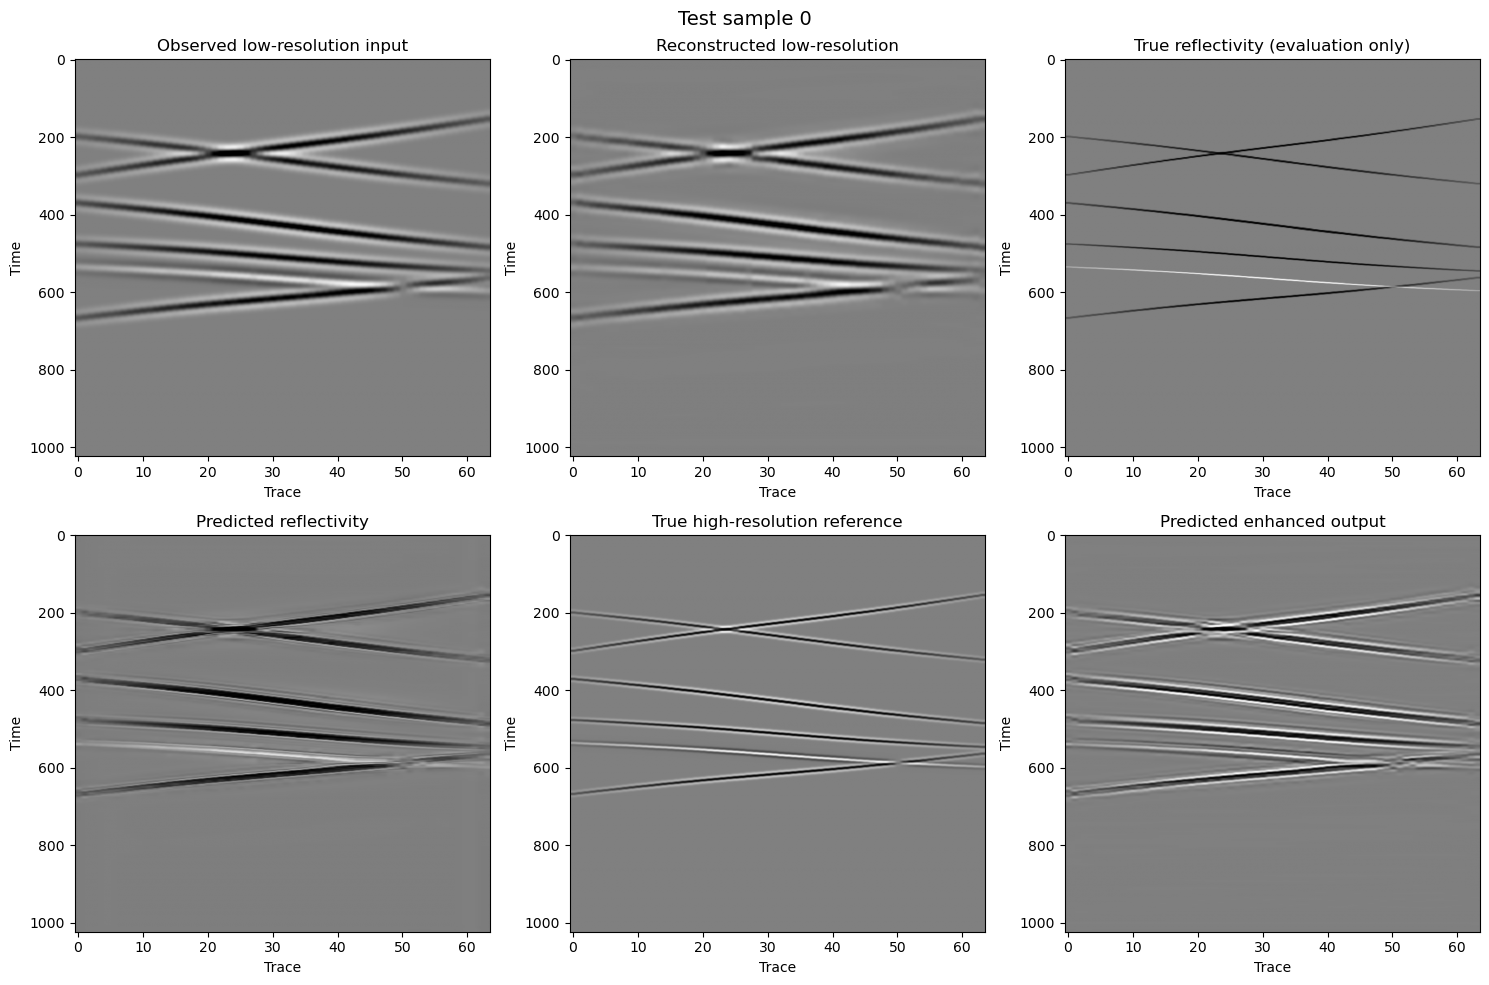

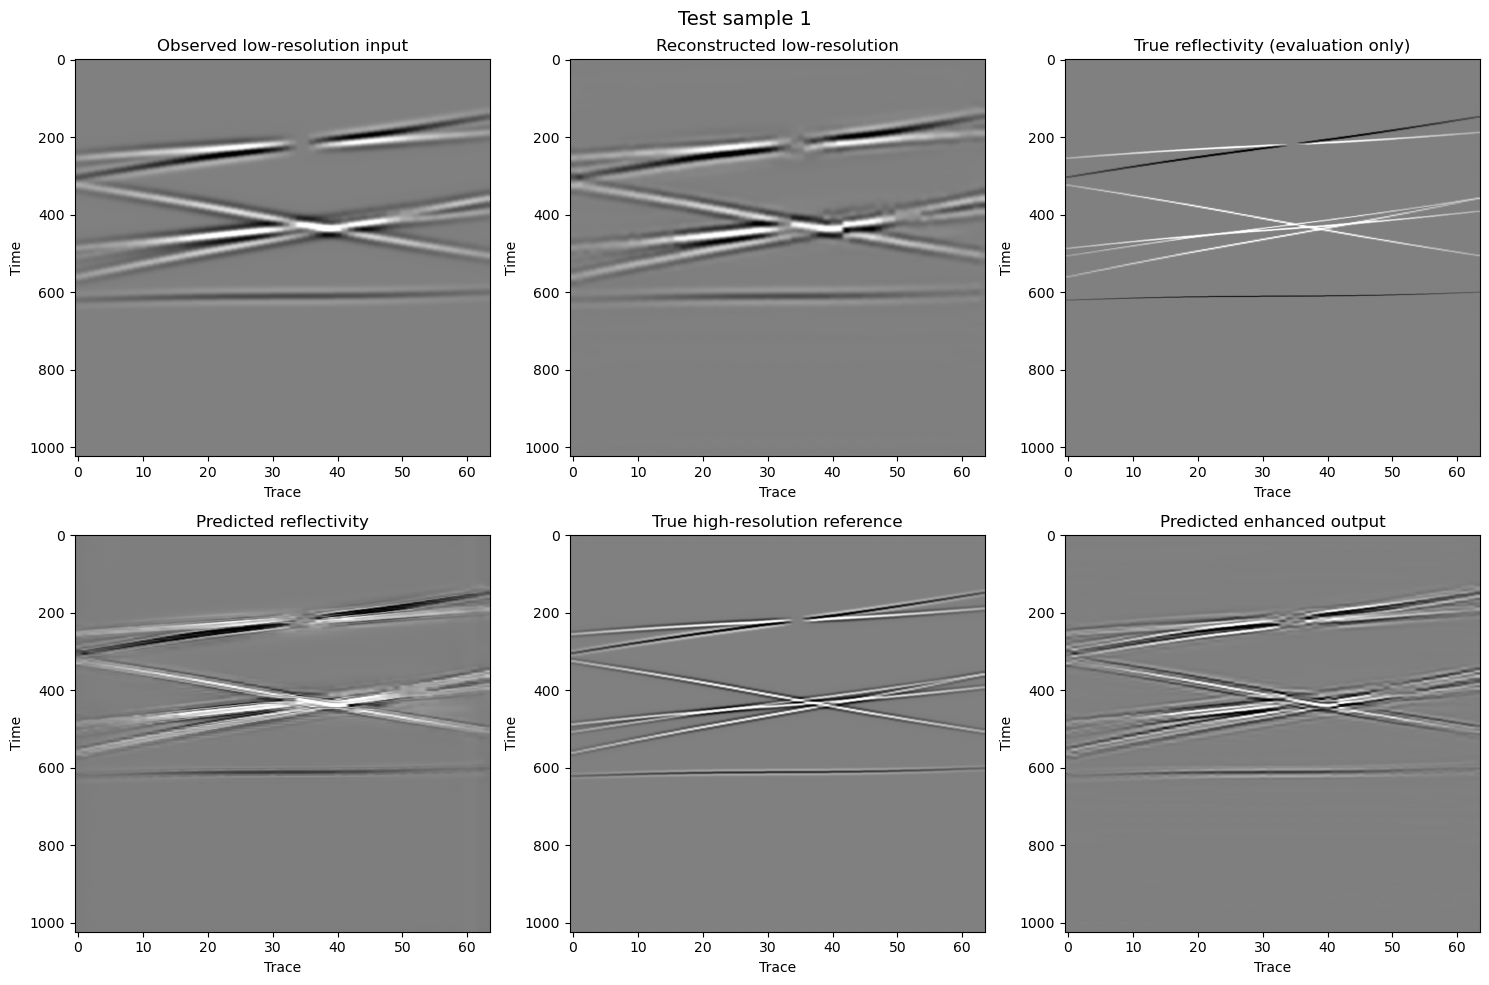

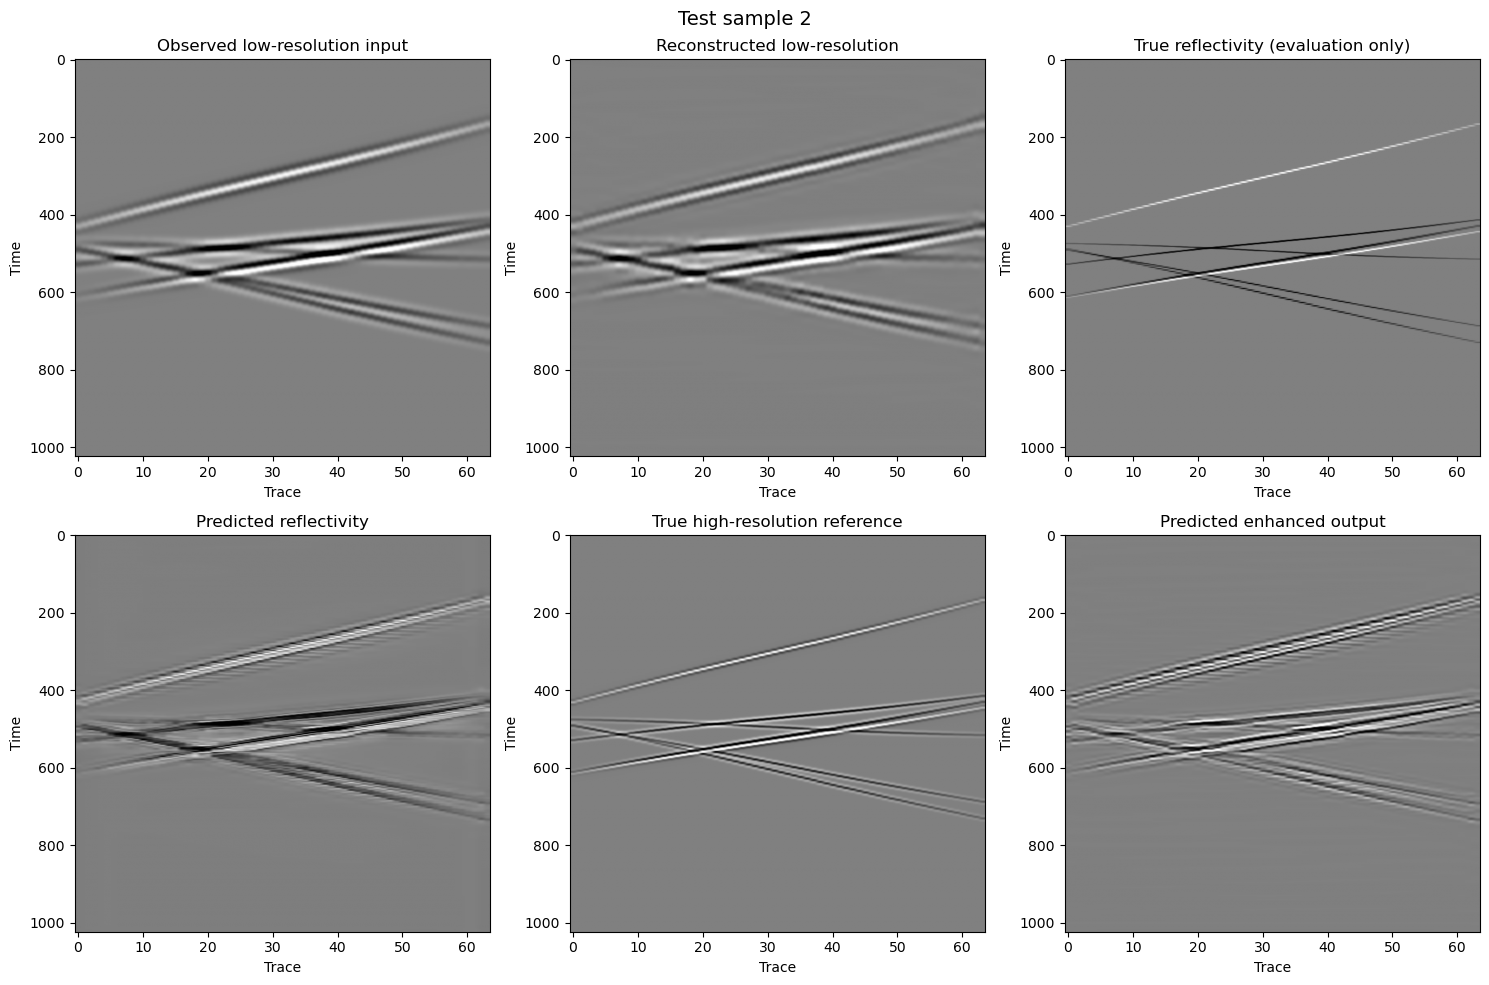

In [18]:

def visualize_prediction(pred, idx=0):
    y = pred["y_low"]
    yrec = pred["y_rec"]
    r = pred["r_true"]
    rhat = pred["r_hat"]
    xh = pred["xh_true"]
    xhp = pred["xh_pred"]

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    items = [
        (y, "Observed low-resolution input"),
        (yrec, "Reconstructed low-resolution"),
        (r, "True reflectivity (evaluation only)"),
        (rhat, "Predicted reflectivity"),
        (xh, "True high-resolution reference"),
        (xhp, "Predicted enhanced output"),
    ]

    for ax, (img, ttl) in zip(axes.ravel(), items):
        vmax = np.percentile(np.abs(img), 99.5) + 1e-12
        ax.imshow(img, aspect="auto", cmap="gray", vmin=-vmax, vmax=vmax)
        ax.set_title(ttl)
        ax.set_xlabel("Trace")
        ax.set_ylabel("Time")

    fig.suptitle(f"Test sample {idx}", fontsize=14)
    plt.tight_layout()
    plt.show()

for i in range(min(3, len(test_preds))):
    visualize_prediction(test_preds[i], idx=i)

## Resolution transfer experiment

One important benefit of this reflectivity-first formulation is that once $\widehat{r}$ is obtained, you can generate **multiple target resolutions** simply by changing the target wavelet.

This makes the method useful not only for a single fixed enhancement setting, but for a family of author-defined output resolutions.

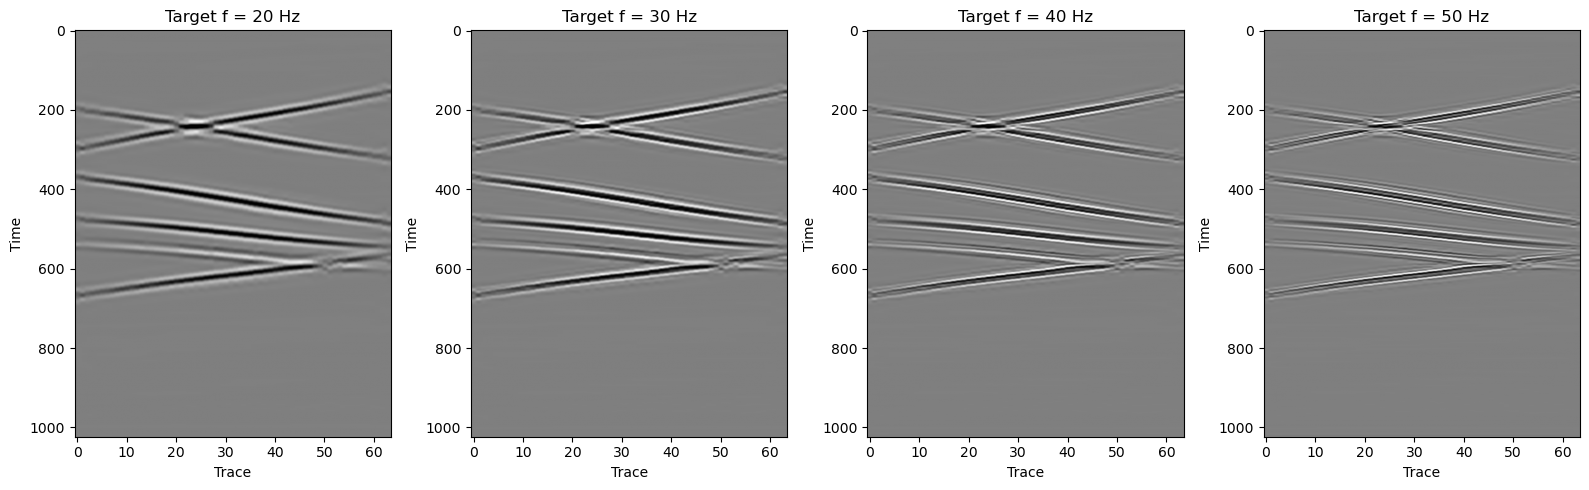

In [19]:

target_freqs = [20.0, 30.0, 40.0, 50.0]
sample = test_preds[0]
rhat0 = torch.tensor(sample["r_hat"][None, None, ...], dtype=torch.float32, device=device)

fig, axes = plt.subplots(1, len(target_freqs), figsize=(4 * len(target_freqs), 5))
for ax, f in zip(axes, target_freqs):
    _, wt = ricker(f, CFG["dt"], CFG["wavelet_length_s"])
    wt = torch.tensor(wt, dtype=torch.float32, device=device)
    out = conv_time_torch(rhat0, wt)[0, 0].detach().cpu().numpy()
    vmax = np.percentile(np.abs(out), 99.5) + 1e-12
    ax.imshow(out, aspect="auto", cmap="gray", vmin=-vmax, vmax=vmax)
    ax.set_title(f"Target f = {f:.0f} Hz")
    ax.set_xlabel("Trace")
    ax.set_ylabel("Time")

plt.tight_layout()
plt.show()

## Discussion: known-wavelet vs blind-wavelet workflows

### Case A: known low wavelet
Use this when:
- the acquisition wavelet is known or controlled
- you want the most stable inversion
- you want a pure self-supervised inverse problem

### Case B: semi-blind low wavelet
Use this when:
- the low wavelet is only approximately known
- you can estimate a dominant frequency from the observed data
- you want to refine the wavelet during training

### Practical interpretation
This workflow is conceptually close to:

1. **deconvolution / inverse filtering** to recover reflectivity
2. **wavelet substitution / reconvolution** to synthesize desired resolution

Deep learning helps because the network learns a data-adaptive inverse mapping with structural priors.

In [20]:

# Save results
save_dir = Path(CFG["save_dir"])
save_dir.mkdir(parents=True, exist_ok=True)

torch.save(model.state_dict(), save_dir / "model_selfsupervised_resolution.pt")
np.save(save_dir / "history.npy", np.array(history, dtype=object), allow_pickle=True)

if CFG["blind_mode"]:
    np.save(save_dir / "learned_low_wavelet.npy", wavelet_module().detach().cpu().numpy())

with open(save_dir / "test_summary.json", "w") as f:
    json.dump(test_summary, f, indent=2)

print("Saved artifacts to:", save_dir.resolve())

Saved artifacts to: /Users/chenyk/xinyue-SWAN/notebooks/runs_selfsupervised_resolution


## What can you adjust?

You can now re-run the notebook with different values of:

- `low_freq_hz`
- `high_freq_hz`
- `blind_mode`
- `blind_init_mode`
- `noise_std`

to explore many resolution-enhancement scenarios from the same reflectivity dataset.

## Main takeaways

- The dataset stores **reflectivity**, which is ideal for flexible resolution-enhancement research.
- Training can be **self-supervised** by matching the reconvolved prediction to the low-resolution observation.
- The enhanced output is generated by **reconvolving the estimated reflectivity** with a target wavelet.
- A **semi-blind wavelet-learning** option makes the method useful when the input wavelet is not fully known.
- Once reflectivity is estimated, the same patch can be rendered at **many target resolutions**.

---

## Homework?

- add a frequency-domain loss
- add a multiscale SSIM-style reconstruction loss on the low-resolution match
- predict reflectivity plus uncertainty
- use a transformer or diffusion prior instead of a U-Net
- move from patchwise training to full-gather or overlapping-window inference